<a href="https://colab.research.google.com/github/bugraaksu1/DS570_Project/blob/Development_Workspace/notebooks/Project_Test_Workspace.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

def fetch_dataset(url):
    """
    Downloads the finalized dataset from the repository.
    """
    print(f"Attempting to retrieve dataset from: {url}")
    try:
        # Specified semicolon separator and comma decimal to handle localized CSV formatting
        data = pd.read_csv(url, sep=';', decimal=',')
        print("Dataset successfully ingested.")
        return data
    except Exception as error:
        print(f"Critical error during data acquisition: {error}")
        return None

if __name__ == "__main__":
    REPO_URL = "https://raw.githubusercontent.com/bugraaksu1/DS570_Project/main/data/Finalized_Dataset.csv"
    df = fetch_dataset(REPO_URL)

    if df is not None:
        display(df.head())
        print("\nSchema Metadata:")
        print(df.dtypes)


Attempting to retrieve dataset from: https://raw.githubusercontent.com/bugraaksu1/DS570_Project/main/data/Finalized_Dataset.csv
Dataset successfully ingested.


,TimeStamp,Signal_X1,Signal_X2,Signal_X3,Signal_X4,Signal_X5,Signal_X6,Signal_X7,Signal_X8,Signal_X9,Signal_X10,Signal_X11,Signal_Y
0,0.015,0.3742,0.5452,0.5006,0.8425,0.1429,0.7508,0.0,0.0435,0.0,0.0,0.0,0.0
1,0.025,0.3743,0.5452,0.5017,0.8425,0.1714,0.7508,0.0,0.0435,0.0,0.0,0.0,0.0
2,0.035,0.3746,0.5452,0.5029,0.8420,0.1714,0.7508,0.0,0.0435,0.0,0.0,0.0,0.0
3,0.045,0.3747,0.5437,0.5032,0.8420,0.1714,0.7508,0.0,0.0435,0.0,0.0,0.0,0.0
4,0.055,0.3748,0.5424,0.5035,0.8420,0.2000,0.7508,0.0,0.0435,0.0,0.0,0.0,0.0



Schema Metadata:
TimeStamp     float64
Signal_X1     float64
Signal_X2     float64
Signal_X3     float64
Signal_X4     float64
Signal_X5     float64
Signal_X6     float64
Signal_X7     float64
Signal_X8     float64
Signal_X9     float64
Signal_X10    float64
Signal_X11    float64
Signal_Y      float64
dtype: object


### Model Implementation: Linear Regression
In this section, we implement a baseline Linear Regression model to establish a performance benchmark for signal prediction.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib

def execute_regression_pipeline(data):
    """
    Extracts features, trains a linear model, and evaluates performance.
    """
    # Feature selection based on signal input columns
    feature_cols = [f'Signal_X{i}' for i in range(1, 12)]
    X = data[feature_cols]
    y = data['Signal_Y']

    print(f"Input Features: {feature_cols}")

    # Hold-out validation split (80/20)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Model initialization and fitting
    regressor = LinearRegression()
    regressor.fit(X_train, y_train)

    # Inference and Metric calculation
    predictions = regressor.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    print("\n--- Baseline Model Metrics ---")
    print(f"MSE: {mse:.6f}")
    print(f"R-squared: {r2:.6f}")

    # Serialize model for deployment
    artifact_path = 'linear_model.joblib'
    joblib.dump(regressor, artifact_path)
    print(f"\nModel artifact persisted to: {artifact_path}")

    return regressor

if __name__ == "__main__":
    if 'df' in locals() and df is not None:
        model = execute_regression_pipeline(df)
    else:
        print("Environment Error: Dataframe 'df' is not defined.")

Input Features: ['Signal_X1', 'Signal_X2', 'Signal_X3', 'Signal_X4', 'Signal_X5', 'Signal_X6', 'Signal_X7', 'Signal_X8', 'Signal_X9', 'Signal_X10', 'Signal_X11']

--- Baseline Model Metrics ---
MSE: 0.000005
R-squared: 0.999900

Model artifact persisted to: linear_model.joblib


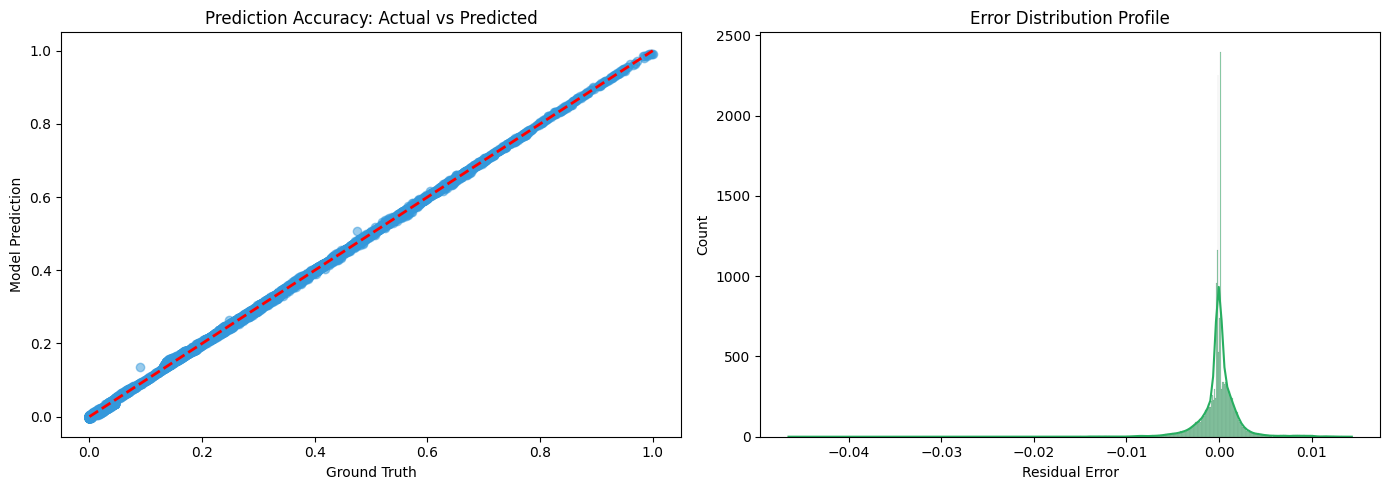

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib
from sklearn.model_selection import train_test_split

# Prepare evaluation data
feature_cols = [f'Signal_X{i}' for i in range(1, 12)]
X = df[feature_cols]
y = df['Signal_Y']

# Replicating the test split for visualization
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Load artifact and generate predictions
predictor = joblib.load('linear_model.joblib')
y_hat = predictor.predict(X_test)

# Visual Diagnostics
plt.figure(figsize=(14, 5))

# Plot 1: Actual vs Predicted
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_hat, alpha=0.5, color='#3498db')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Ground Truth')
plt.ylabel('Model Prediction')
plt.title('Prediction Accuracy: Actual vs Predicted')

# Plot 2: Residual Analysis
plt.subplot(1, 2, 2)
residuals = y_test - y_hat
sns.histplot(residuals, kde=True, color='#27ae60')
plt.xlabel('Residual Error')
plt.title('Error Distribution Profile')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

# Robustness check using 5-fold cross-validation
cv_scores = cross_val_score(LinearRegression(), X, y, cv=5, scoring='r2')

print("--- Cross-Validation Analysis (k=5) ---")
print(f"Fold R2 Scores: {cv_scores}")
print(f"Mean R2 Score: {cv_scores.mean():.6f}")
print(f"Standard Deviation: {cv_scores.std():.6f}")

if cv_scores.std() < 0.01:
    print("\nStability Check: Passed. Low variance suggests model robustness.")
else:
    print("\nStability Check: Caution. Significant variance observed in fold performance.")

--- Cross-Validation Analysis (k=5) ---
Fold R2 Scores: [0.99884379 0.99992082 0.99997949 0.99964414 0.99976046]
Mean R2 Score: 0.999630
Standard Deviation: 0.000410

Stability Check: Passed. Low variance suggests model robustness.


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Initializing Random Forest with 100 estimators for non-linear exploration
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)

# Utilizing the same hold-out split from previous steps
X_train_sub, X_test_sub, y_train_sub, y_test_sub = train_test_split(X, y, test_size=0.2, random_state=42)

print("Fitting Random Forest model...")
rf_regressor.fit(X_train_sub, y_train_sub)

# Performance Metrics
y_hat_rf = rf_regressor.predict(X_test_sub)
mse_rf = mean_squared_error(y_test_sub, y_hat_rf)
r2_rf = r2_score(y_test_sub, y_hat_rf)

print("\n--- Random Forest Ensemble Results ---")
print(f"MSE: {mse_rf:.6f}")
print(f"R2 Score: {r2_rf:.6f}")

print("\n--- Model Comparison Summary ---")
print(f"Linear Regression R2: 0.999900")
print(f"Random Forest R2: {r2_rf:.6f}")

Fitting Random Forest model...

--- Random Forest Ensemble Results ---
MSE: 0.000001
R2 Score: 0.999979

--- Model Comparison Summary ---
Linear Regression R2: 0.999900
Random Forest R2: 0.999979


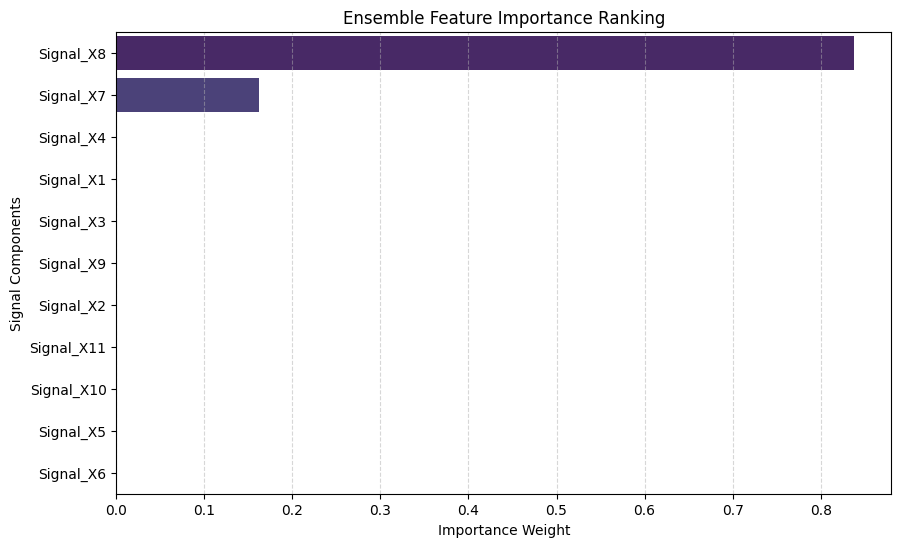

Top 3 Significant Predictors:
Signal_X8: 83.82%
Signal_X7: 16.17%
Signal_X4: 0.00%


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract and rank feature importance weights
weights = rf_regressor.feature_importances_
importance_map = pd.DataFrame({
    'Feature': [f'Signal_X{i}' for i in range(1, 12)],
    'Importance': weights
}).sort_values(by='Importance', ascending=False)

# Visualization of Feature Significance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_map, hue='Feature', palette='viridis', legend=False)
plt.title('Ensemble Feature Importance Ranking')
plt.xlabel('Importance Weight')
plt.ylabel('Signal Components')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

# Log top influential predictors
top_features = importance_map.head(3)
print("Top 3 Significant Predictors:")
for idx, row in top_features.iterrows():
    print(f"{row['Feature']}: {row['Importance']*100:.2f}%")